# Eigenfaces: Face Compression and Recognition

**Team 01 · Mathematics Project · PCA from scratch with NumPy**

**Question.** A face image has 64 × 64 = 4,096 pixels. How few numbers $k$ are enough to **rebuild** the face well, and to still **recognise** who it is?

**Idea.** PCA learns the main patterns of variation in the training faces, called **eigenfaces**. Any face can then be stored as $k$ weights, one per eigenface.

**Team 01 hypothesis.** Reconstruction error falls as $k$ grows, but each extra component helps less than the one before. We test $k \in \{1, 5, 10, 20, 50, 100, 150, 250\}$.

**Train vs test.** PCA is learned from the training images only. Every result is reported for the **training set** (faces PCA has seen) and for the **test set** (new photos of the same 40 people). The gap between the two shows how well the eigenfaces generalise.

| Section | Content |
|---|---|
| 1 | Data and train / validation / test split |
| 2 | Mean face and centering |
| 3 | Eigenfaces (PCA) |
| 4 | Reconstruction error and explained variance |
| 5 | Reconstructed faces |
| 6 | Choosing $k$: elbow and silhouette |
| 7 | Face recognition with KNN |
| 8 | Metric tables |
| 9 | Five-fold cross-validation |
| 10 | Summary |

NumPy implements PCA and KNN; scikit-learn only loads the data and computes the metrics. Random seed: 42. Run the cells from top to bottom.

*Source: Math-Project-Kickoff.pdf (project brief), pp. 2–5 for the common workflow and pp. 6–7 for the Team 01 task.*

## 1. Data and Split

**Olivetti Faces:** 400 grayscale images (64 × 64) of 40 people, 10 images each.

Each person's 10 images are shuffled once (seed 42) and cut into 5 pairs. In round $f$ ($f = 1, \dots, 5$):

| Pair | Role |
|---|---|
| pair $f$ | **test** |
| pair $f+1$ (wrapping 5 → 1) | one image to **validation**, one to **training** |
| the other 3 pairs | **training** |

So every round has **280 train / 40 validation / 80 test** images, i.e. 7 / 1 / 2 per person (70 / 10 / 20 %). Over the five rounds, every image is tested exactly once.

Sections 2–8 use **round 1**. Section 9 repeats the whole pipeline on all five rounds.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
faces = fetch_olivetti_faces()
X, y = faces.data, faces.target          # X: (400, 4096) pixel vectors, y: person id 0-39

rng = np.random.default_rng(seed=42)

# Shuffle each person's 10 image indices once and cut them into 5 pairs
person_pairs = []
for person in np.unique(y):
    person_indices = np.where(y == person)[0]
    assert len(person_indices) == 10, "This split needs 10 images per person."
    person_pairs.append(rng.permutation(person_indices).reshape(5, 2))

folds = []
for fold_id in range(5):
    val_pair = (fold_id + 1) % 5
    train_idx, val_idx, test_idx = [], [], []

    for pairs in person_pairs:
        for pair_id, (first, second) in enumerate(pairs):
            if pair_id == fold_id:
                test_idx += [first, second]
            elif pair_id == val_pair:
                val_idx.append(first)
                train_idx.append(second)
            else:
                train_idx += [first, second]

    folds.append((np.array(train_idx), np.array(val_idx), np.array(test_idx)))

# Sanity checks: right sizes, no overlap, every image tested exactly once
for train_idx, val_idx, test_idx in folds:
    assert (len(train_idx), len(val_idx), len(test_idx)) == (280, 40, 80)
    assert len(np.unique(np.concatenate([train_idx, val_idx, test_idx]))) == len(y)
assert np.array_equal(np.sort(np.concatenate([fold[2] for fold in folds])), np.arange(len(y)))

# Round 1 is used in Sections 2-8
train_idx, val_idx, test_idx = folds[0]
X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

print("All data:  ", X.shape)
print("Training:  ", X_train.shape)
print("Validation:", X_val.shape)
print("Test:      ", X_test.shape)

All data:   (400, 4096)
Training:   (280, 4096)
Validation: (40, 4096)
Test:       (80, 4096)


## 2. Mean Face and Centering

The **mean face** is the pixel-by-pixel average of the $N = 280$ training images:

$$\mu = \frac{1}{N}\sum_{i=1}^{N} x_i$$

**Centering** subtracts it from an image, $x_c = x - \mu$, leaving only what makes that face different from the average one. Validation and test images are always centred with this same **training** mean.

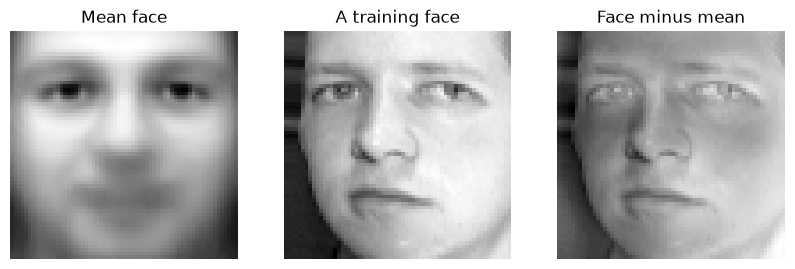

In [3]:
mean_face = X_train.mean(axis=0)            # shape (4096,)
face = X_train[1]

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
panels = [(mean_face, "Mean face"), (face, "A training face"), (face - mean_face, "Face minus mean")]
for ax, (image, title) in zip(axes, panels):
    ax.imshow(image.reshape(64, 64), cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.show()

Subtracting a constant shifts each pixel's values but not their spread, so the variance should be the same before and after centering:

In [4]:
X_train_centered = X_train - mean_face

print("Average pixel variance before centering:", np.var(X_train, axis=0).mean())
print("Average pixel variance after centering: ", np.var(X_train_centered, axis=0).mean())

Average pixel variance before centering: 0.01931817
Average pixel variance after centering:  0.01931817


## 3. Eigenfaces (PCA)

The covariance matrix of the centred training images shows which pixels vary together:

$$C = \frac{X_c^{T} X_c}{N - 1} \qquad (4096 \times 4096)$$

- Its **eigenvectors** are the **eigenfaces**: 4,096-pixel patterns that describe how faces differ from the mean.
- Its **eigenvalues** $\lambda$ give how much the faces vary along each eigenface.

`np.linalg.eigh` returns eigenvalues from smallest to largest, so we reverse the order to make component 1 the most important. With $N = 280$ images at most $N - 1 = 279$ eigenvalues are non-zero, so 279 is the largest useful $k$.

`fit_pca` bundles these steps so that Section 9 can repeat them on every round.

In [5]:
def fit_pca(X_train):
    # Mean face plus eigenvalues/eigenvectors of the training covariance, largest first
    mean_face = X_train.mean(axis=0)
    X_centered = X_train - mean_face
    cov_matrix = X_centered.T @ X_centered / (len(X_train) - 1)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)    # ascending order
    order = np.argsort(eigenvalues)[::-1]                     # largest variance first
    return mean_face, eigenvalues[order], eigenvectors[:, order]


mean_face, eigenvalues_sorted, eigenvectors_sorted = fit_pca(X_train)

print("Eigenface matrix:", eigenvectors_sorted.shape, "(one eigenface per column)")
print("Largest 10 eigenvalues:", np.round(eigenvalues_sorted[:10], 3))

Eigenface matrix: (4096, 4096) (one eigenface per column)
Largest 10 eigenvalues: [18.31  11.387  6.251  4.129  2.926  2.623  1.964  1.733  1.593  1.412]


## 4. Reconstruction Error and Explained Variance

Let $U_k$ hold the first $k$ eigenfaces (4096 × $k$).

| Step | Formula | Meaning |
|---|---|---|
| Compress | $Z = (X - \mu)\,U_k$ | each face becomes $k$ numbers |
| Reconstruct | $\hat X = Z\,U_k^{T} + \mu$ | $k$ numbers back to 4,096 pixels |
| Error | $\mathrm{MSE} = \frac{1}{n \cdot 4096}\sum_{i,j}(X_{ij} - \hat X_{ij})^2$ | lower is closer to the original |

**Explained variance** is the share of the faces' variation that the first $k$ eigenfaces keep:

- Train: $\;V(k) = \dfrac{\sum_{j \le k}\lambda_j}{\sum_{j}\lambda_j}$
- Test: $\;V_{\text{test}}(k) = \dfrac{\lVert (X_{\text{test}} - \mu)\,U_k \rVert^2}{\lVert X_{\text{test}} - \mu \rVert^2}$

The test formula is the same idea applied to faces PCA never saw; on training images both formulas give the same number.

In [6]:
def project_to_pca(X, mean_face, eigenvectors, k):
    # Compress: Z = (X - mu) U_k, i.e. k numbers per face
    return (X - mean_face) @ eigenvectors[:, :k]


def reconstruct(X, mean_face, eigenvectors, k):
    # Decompress: X_hat = Z U_k^T + mu
    Z = project_to_pca(X, mean_face, eigenvectors, k)
    return Z @ eigenvectors[:, :k].T + mean_face


def reconstruction_error(X, mean_face, eigenvectors, k):
    # Mean squared error over all images and pixels
    return np.mean((X - reconstruct(X, mean_face, eigenvectors, k)) ** 2)

### 4.1 Results Table

MSE and explained variance for each tested $k$. Both columns use the same eigenfaces, learned from the training images only.

In [7]:
max_k = min(X_train.shape[0] - 1, X_train.shape[1])     # 279 non-zero components at most
k_values = [k for k in [1, 5, 10, 20, 50, 100, 150, 250] if k <= max_k]

# Cumulative explained variance for every k = 1 ... max_k
train_variance = np.cumsum(eigenvalues_sorted[:max_k]) / np.sum(eigenvalues_sorted)
Z_test = project_to_pca(X_test, mean_face, eigenvectors_sorted, max_k)
test_variance = np.cumsum(np.sum(Z_test ** 2, axis=0)) / np.sum((X_test - mean_face) ** 2)

pca_table = pd.DataFrame({
    "k": k_values,
    "train MSE": [reconstruction_error(X_train, mean_face, eigenvectors_sorted, k) for k in k_values],
    "test MSE": [reconstruction_error(X_test, mean_face, eigenvectors_sorted, k) for k in k_values],
    "train variance": [train_variance[k - 1] for k in k_values],
    "test variance": [test_variance[k - 1] for k in k_values],
})
pca_table

,k,train MSE,test MSE,train variance,test variance
0,1,0.014864,0.014390,0.230574,0.251634
1,5,0.008857,0.008674,0.541528,0.548897
2,10,0.006588,0.006828,0.658960,0.644914
3,20,0.004455,0.005052,0.769402,0.737268
4,50,0.002239,0.003368,0.884118,0.824858
5,100,0.001010,0.002500,0.947706,0.869970
6,150,0.000467,0.002112,0.975807,0.890186
7,250,0.000040,0.001715,0.997920,0.910787


### 4.2 Error and Variance Curves

Left: MSE at the tested $k$ values. Right: explained variance for every $k$ up to 279, with dashed lines at 90 %, 95 % and 99 %. The table under the plot gives the smallest $k$ that reaches each level.

Explained variance measures reconstruction only: keeping 95 % of the variance does **not** mean 95 % recognition accuracy.

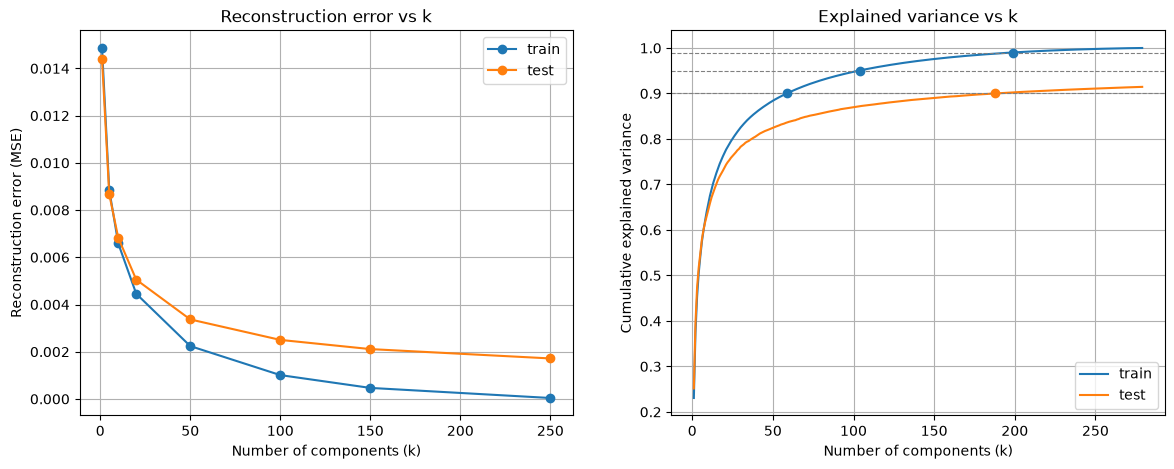

Test variance kept with all 279 components: 0.915


,threshold,k needed (train),k needed (test)
0,0.90,59,188
1,0.95,104,not reached
2,0.99,199,not reached


In [8]:
thresholds = [0.90, 0.95, 0.99]

def components_needed(variance_curve, threshold):
    # Smallest k whose cumulative explained variance reaches the threshold (None if never)
    reached = np.flatnonzero(variance_curve >= threshold)
    return int(reached[0]) + 1 if reached.size else None


fig, (ax_mse, ax_var) = plt.subplots(1, 2, figsize=(14, 5))

for split, variance in [("train", train_variance), ("test", test_variance)]:
    ax_mse.plot(k_values, pca_table[f"{split} MSE"], marker="o", label=split)
    line, = ax_var.plot(np.arange(1, max_k + 1), variance, label=split)
    for t in thresholds:
        k_t = components_needed(variance, t)
        if k_t is not None:
            ax_var.scatter(k_t, t, color=line.get_color(), zorder=3)

for t in thresholds:
    ax_var.axhline(t, color="gray", linestyle="--", linewidth=0.8)

ax_mse.set(xlabel="Number of components (k)", ylabel="Reconstruction error (MSE)", title="Reconstruction error vs k")
ax_var.set(xlabel="Number of components (k)", ylabel="Cumulative explained variance", title="Explained variance vs k")
for ax in (ax_mse, ax_var):
    ax.grid()
    ax.legend()
plt.show()

print(f"Test variance kept with all {max_k} components: {test_variance[-1]:.3f}")
pd.DataFrame({
    "threshold": thresholds,
    "k needed (train)": [components_needed(train_variance, t) or "not reached" for t in thresholds],
    "k needed (test)": [components_needed(test_variance, t) or "not reached" for t in thresholds],
})

**What this shows**

- **Diminishing returns.** Both errors drop fast for small $k$ and then level off. This supports the Team 01 hypothesis; Section 6 locates the bend at $k = 50$.
- **Train vs test.** Up to about $k = 10$ the two errors are almost equal: the first eigenfaces capture broad patterns, such as lighting and face shape, that every photo shares. After that the gap grows. At $k = 250$ the training error is almost zero, while the test error is still about half of its value at $k = 50$.
- **A ceiling for new faces.** Training variance reaches 100 % at $k = 279$, but test variance stops at about 91.5 %. The remaining ~8.5 % of a new photo cannot be built from any combination of the 280 training faces, so no number of eigenfaces recovers it. This is why 95 % and 99 % are "not reached" on test.
- **Training thresholds are optimistic.** Keeping 90 % of the training variance takes 59 components; keeping 90 % of the test variance takes 188.

## 5. Reconstructed Faces

Each row is one person: the original photo, then its reconstruction from $k$ = 10, 50, 100 and 150 components. Storing $k$ weights instead of 4,096 pixels shrinks each face by a factor of $4096/k$ (the mean face and the eigenfaces are shared, so they are stored only once).

The first grid uses training photos; the second uses **test** photos of the same four people.

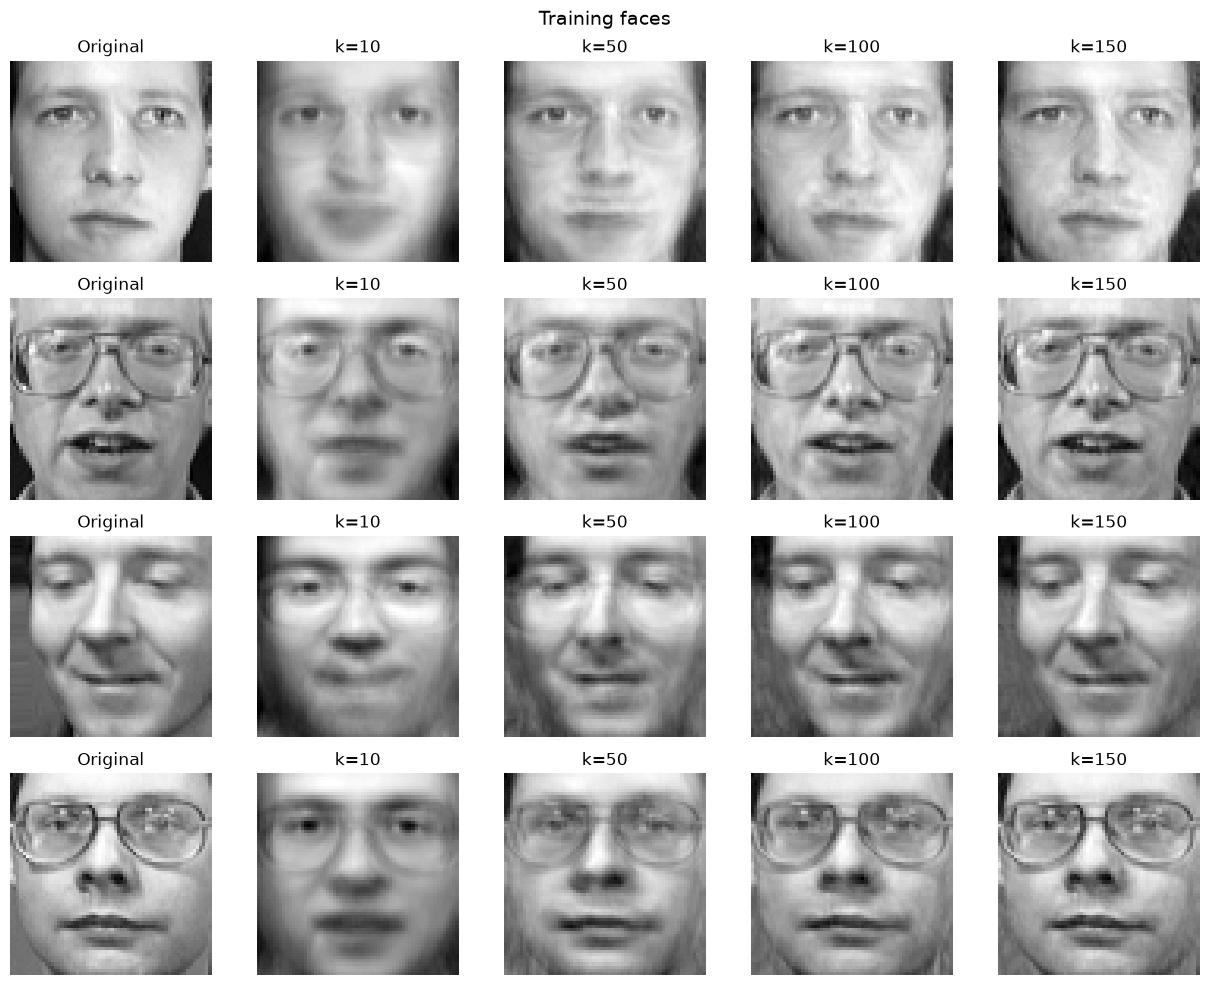

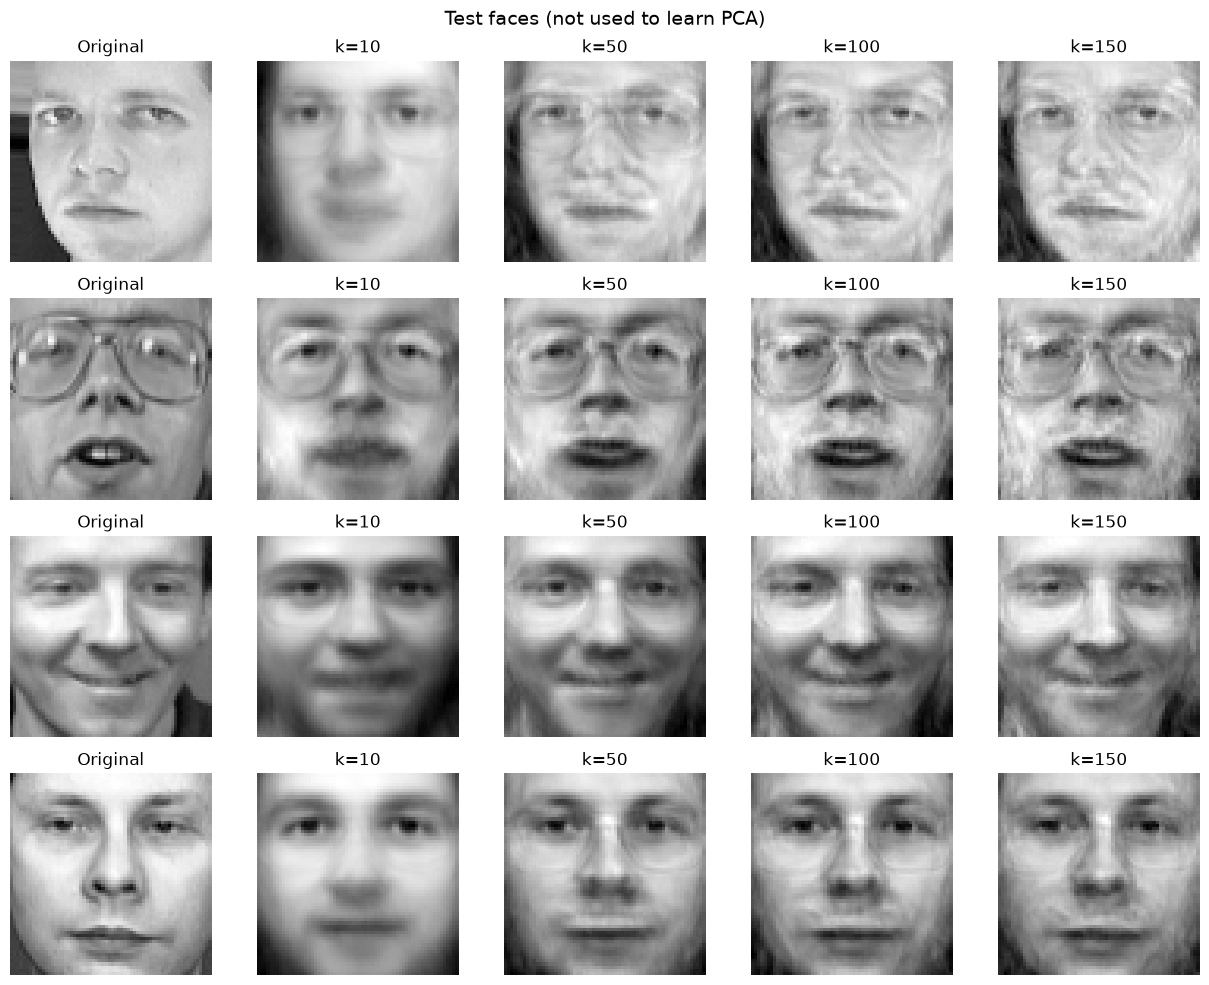

In [9]:
def show_reconstructions(X, labels, mean_face, eigenvectors, k_values, title, n_people=4):
    # One row per person: their first image in X, then its reconstruction for each k
    rows = [np.where(labels == person)[0][0] for person in np.unique(labels)[:n_people]]
    fig, axes = plt.subplots(len(rows), len(k_values) + 1,
                             figsize=(2.5 * (len(k_values) + 1), 2.5 * len(rows)))
    for row_axes, idx in zip(axes, rows):
        images = [X[idx]] + [reconstruct(X[idx], mean_face, eigenvectors, k) for k in k_values]
        titles = ["Original"] + [f"k={k}" for k in k_values]
        for ax, image, subtitle in zip(row_axes, images, titles):
            ax.imshow(image.reshape(64, 64), cmap="gray")
            ax.set_title(subtitle)
            ax.axis("off")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


k_values_visual = [10, 50, 100, 150]
show_reconstructions(X_train, y_train, mean_face, eigenvectors_sorted, k_values_visual, "Training faces")
show_reconstructions(X_test, y_test, mean_face, eigenvectors_sorted, k_values_visual, "Test faces (not used to learn PCA)")

**What to look for**

- $k = 10$ gives only a blurred, generic face; by $k = 50$ each person is recognisable.
- Training faces are almost identical to the original by $k = 100$–$150$.
- Test faces improve too but never become as sharp, and they pick up "ghost" details from other training faces, e.g. faint glasses on people who are not wearing glasses in that photo. This is the ceiling from Section 4: a new face can only be drawn with patterns found in the training faces.

## 6. How Many Components?

### 6.1 Elbow Method

Draw a straight line from the first to the last point of the MSE curve. The **elbow** is the tested $k$ farthest from that line, where the curve bends from steep to flat. It is a reasonable candidate, not a guaranteed optimum, because it depends on which $k$ values were tested.

Elbow k (train): 50
Elbow k (test): 50


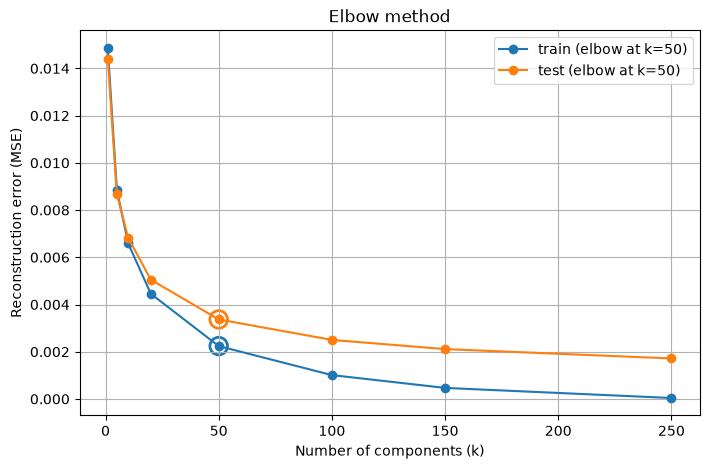

In [10]:
def elbow_point(k_values, errors):
    # Tested k farthest from the line joining the first and last points of the error curve
    k = np.asarray(k_values, dtype=float)
    e = np.asarray(errors, dtype=float)
    dk, de = k[-1] - k[0], e[-1] - e[0]
    distances = np.abs(dk * (e[0] - e) - de * (k[0] - k)) / np.hypot(dk, de)
    return k_values[np.argmax(distances)]


plt.figure(figsize=(8, 5))
for split in ["train", "test"]:
    errors = pca_table[f"{split} MSE"].to_numpy()
    best_k = elbow_point(k_values, errors)
    line, = plt.plot(k_values, errors, marker="o", label=f"{split} (elbow at k={best_k})")
    plt.scatter(best_k, errors[k_values.index(best_k)], s=160,
                facecolors="none", edgecolors=line.get_color(), linewidths=2)
    print(f"Elbow k ({split}): {best_k}")

plt.xlabel("Number of components (k)")
plt.ylabel("Reconstruction error (MSE)")
plt.title("Elbow method")
plt.grid()
plt.legend()
plt.show()

### 6.2 Silhouette Score

This asks a recognition question: in PCA space, do photos of the same person sit close together and away from other people? For each face $i$:

$$s(i) = \frac{b(i) - a(i)}{\max\big(a(i),\, b(i)\big)}$$

- $a(i)$: average distance to the other photos of the **same** person
- $b(i)$: average distance to the photos of the **closest other** person

$s \approx 1$ means people are well separated, $s \approx 0$ means they overlap, and $s < 0$ means the face is closer to someone else. We report the mean score over all faces. In round 1 each person has only 2 test photos, so the test score is based on fewer distances.

Best k by silhouette (train): 20
Best k by silhouette (test): 50


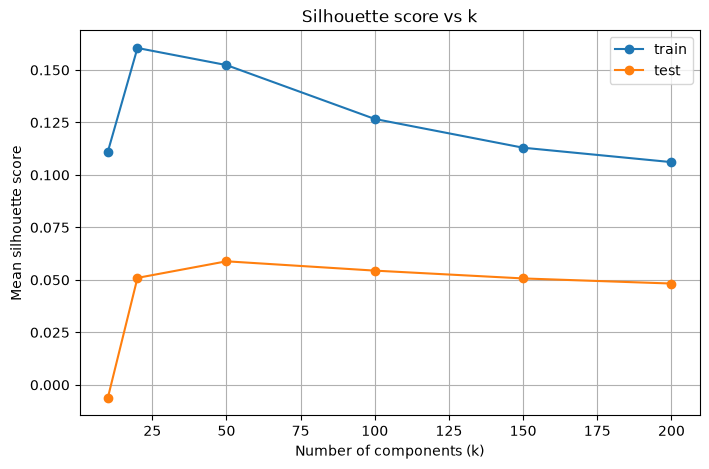

,k,train,test
0,10,0.110993,-0.006254
1,20,0.160467,0.050960
2,50,0.152329,0.058858
3,100,0.126658,0.054421
4,150,0.112965,0.050700
5,200,0.106103,0.048270


In [11]:
def silhouette_method(X, y, mean_face, eigenvectors, k_values):
    # Mean silhouette score of the identity groups in PCA space, for each k
    scores = []
    for k in k_values:
        Z = project_to_pca(X, mean_face, eigenvectors, k)
        sample_scores = []
        for i in range(len(Z)):
            distances = np.linalg.norm(Z - Z[i], axis=1)
            same_person = y == y[i]
            same_person[i] = False
            a = distances[same_person].mean()
            b = min(distances[y == person].mean() for person in np.unique(y) if person != y[i])
            sample_scores.append((b - a) / max(a, b))
        scores.append(np.mean(sample_scores))
    return scores


k_values_silhouette = [10, 20, 50, 100, 150, 200]
silhouette_table = pd.DataFrame({
    "k": k_values_silhouette,
    "train": silhouette_method(X_train, y_train, mean_face, eigenvectors_sorted, k_values_silhouette),
    "test": silhouette_method(X_test, y_test, mean_face, eigenvectors_sorted, k_values_silhouette),
})

plt.figure(figsize=(8, 5))
for split in ["train", "test"]:
    plt.plot(silhouette_table["k"], silhouette_table[split], marker="o", label=split)
    best_k = silhouette_table["k"][silhouette_table[split].idxmax()]
    print(f"Best k by silhouette ({split}): {best_k}")

plt.xlabel("Number of components (k)")
plt.ylabel("Mean silhouette score")
plt.title("Silhouette score vs k")
plt.grid()
plt.legend()
plt.show()

silhouette_table

**What this shows**

- **Elbow:** $k = 50$ on both the training and the test curve, so the train-based choice also holds for new photos.
- **Silhouette:** the best $k$ is small (20 on train, 50 on test) and the score slowly falls after it. The first eigenfaces separate people best; later ones add detail that helps reconstruction but not identity.
- **Low scores overall.** All scores are below 0.2, and test scores are lower still: on average a person's photos are only slightly closer to each other than to the nearest other person. This does not rule out good recognition, because 1-nearest-neighbor only needs the **single** closest photo to be the right person (Section 7).

## 7. Face Recognition with KNN

Each face is replaced by its $k$ PCA coordinates, always computed with the **training** mean and eigenfaces. To identify a face, **KNN** finds the `n_neighbors` closest training faces (Euclidean distance) and takes a majority vote. A tie goes to the smallest label.

Two separate settings are involved:
- **$k$**: how many PCA components describe a face
- **`n_neighbors`**: how many training faces vote

**Metrics** (all between 0 and 1):

| Metric | Meaning |
|---|---|
| Accuracy | share of faces identified correctly |
| Precision | of the faces predicted as person *p*, the share that really are *p* |
| Recall | of person *p*'s faces, the share recognised |
| F1 | harmonic mean of precision and recall |

Precision, recall and F1 are averaged over the 40 people, weighted by their number of images; with this weighting, recall always equals accuracy.

**Validation vs test.** Validation results are used to compare and choose settings. Test results are shown next to them to report how the same settings do on unseen photos; they are never used for choosing (the choice is made in Section 9).

In [12]:
def knn_predict(X_train, y_train, X_query, n_neighbors=1):
    predictions = []
    for x in X_query:
        distances = np.linalg.norm(X_train - x, axis=1)
        nearest_labels = y_train[np.argsort(distances)[:n_neighbors]]
        labels, counts = np.unique(nearest_labels, return_counts=True)
        predictions.append(labels[np.argmax(counts)])     # tie -> smallest label
    return np.array(predictions)


def eval_scores(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def knn_grid(X_train, y_train, query_sets, mean_face, eigenvectors, pca_values, neighbors_values):
    # Score every (PCA k, n_neighbors) pair on each query set, e.g. {"validation": (X_val, y_val)}
    rows = []
    for pca_k in pca_values:
        train_pca = project_to_pca(X_train, mean_face, eigenvectors, pca_k)
        for split, (X_query, y_query) in query_sets.items():
            query_pca = project_to_pca(X_query, mean_face, eigenvectors, pca_k)
            for n in neighbors_values:
                y_pred = knn_predict(train_pca, y_train, query_pca, n)
                rows.append({"split": split, "PCA_k": pca_k, "neighbors": n,
                             **eval_scores(y_query, y_pred)})
    return pd.DataFrame(rows)

### 7.1 Scoring All Settings on Round 1

We score every $k \in \{10, 20, 50, 100, 150, 200, 250\}$ with every `n_neighbors` $\in \{1, 3, 5, 7, 9\}$ on validation and on test. All plots and tables in Sections 7–8 are read from this one result table.

The baseline setting is 50 components with 3 neighbors:

In [13]:
knn_results = knn_grid(
    X_train, y_train,
    {"validation": (X_val, y_val), "test": (X_test, y_test)},
    mean_face, eigenvectors_sorted,
    pca_values=[10, 20, 50, 100, 150, 200, 250],
    neighbors_values=[1, 3, 5, 7, 9],
)


def side_by_side(results):
    # One row per (k, n_neighbors) setting, validation and test metrics next to each other
    return (results.pivot(index=["PCA_k", "neighbors"], columns="split",
                          values=["accuracy", "precision", "recall", "f1"])
                   .swaplevel(axis=1)[["validation", "test"]])


side_by_side(knn_results.query("PCA_k == 50 and neighbors == 3"))

split           validation                                test            \
                  accuracy precision recall        f1 accuracy precision   
PCA_k neighbors                                                            
50    3                0.8      0.75    0.8  0.766667   0.8125  0.838333   

split                              
                 recall        f1  
PCA_k neighbors                    
50    3          0.8125  0.805476

### 7.2 Effect of $k$ and of `n_neighbors`

Left: accuracy as $k$ changes, with 1 neighbor. Right: accuracy as `n_neighbors` changes, with $k = 20$. One extra correct face moves accuracy by 1/40 = 0.025 on validation and by 1/80 = 0.0125 on test.

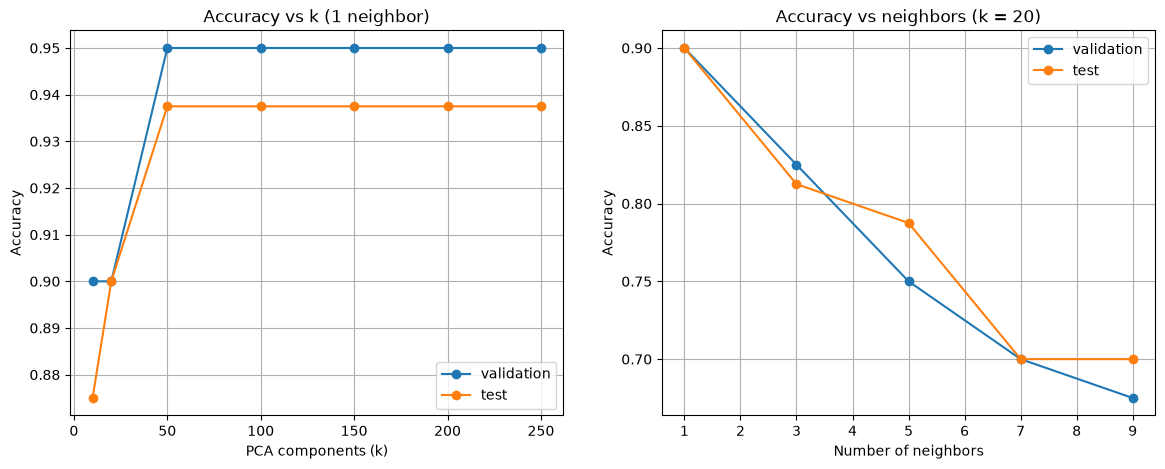

In [14]:
fig, (ax_k, ax_n) = plt.subplots(1, 2, figsize=(14, 5))

for split in ["validation", "test"]:
    by_k = knn_results.query("neighbors == 1 and split == @split")
    by_n = knn_results.query("PCA_k == 20 and split == @split")
    ax_k.plot(by_k["PCA_k"], by_k["accuracy"], marker="o", label=split)
    ax_n.plot(by_n["neighbors"], by_n["accuracy"], marker="o", label=split)

ax_k.set(xlabel="PCA components (k)", ylabel="Accuracy", title="Accuracy vs k (1 neighbor)")
ax_n.set(xlabel="Number of neighbors", ylabel="Accuracy", title="Accuracy vs neighbors (k = 20)")
for ax in (ax_k, ax_n):
    ax.grid()
    ax.legend()
plt.show()

**What this shows**

- **1 neighbor is best.** With $k = 20$, accuracy falls from 0.90 to about 0.70 as the vote grows to 7–9 neighbors. Each person has only 7 training photos, so a large vote pulls in photos of other people.
- **$k$ matters only up to about 50.** With 1 neighbor, accuracy rises until $k = 50$ (validation 0.95, test 0.9375) and then stays flat, even though reconstruction keeps improving (Section 4).
- **Validation and test agree.** Over all 35 settings their accuracies differ by 0.02 on average (less than one validation photo) and never by more than 0.0625, so validation is a fair guide for choosing settings.

## 8. Metric Tables (Validation vs Test)

These tables are slices of the round-1 results from Section 7.1, for $k \le 200$. To see the effect of one setting, compare rows where the other setting is fixed.

### 8.1 Changing $k$ (3 neighbors)

In [15]:
side_by_side(knn_results.query("neighbors == 3 and PCA_k <= 200"))

split           validation                                test            \
                  accuracy precision recall        f1 accuracy precision   
PCA_k neighbors                                                            
10    3              0.750  0.681250  0.750  0.701667   0.7750  0.804167   
20    3              0.825  0.762500  0.825  0.783333   0.8125  0.852083   
50    3              0.800  0.750000  0.800  0.766667   0.8125  0.838333   
100   3              0.850  0.808333  0.850  0.820833   0.8000  0.830000   
150   3              0.850  0.808333  0.850  0.820833   0.8125  0.831250   
200   3              0.850  0.808333  0.850  0.820833   0.8125  0.829167   

split                              
                 recall        f1  
PCA_k neighbors                    
10    3          0.7750  0.767083  
20    3          0.8125  0.808333  
50    3          0.8125  0.805476  
100   3          0.8000  0.791310  
150   3          0.8125  0.800833  
200   3          0.8125  0.800000

### 8.2 Changing `n_neighbors` ($k$ = 100)

In [16]:
side_by_side(knn_results.query("PCA_k == 100"))

split           validation                                test            \
                  accuracy precision recall        f1 accuracy precision   
PCA_k neighbors                                                            
100   1              0.950  0.925000  0.950  0.933333   0.9375  0.954167   
      3              0.850  0.808333  0.850  0.820833   0.8000  0.830000   
      5              0.800  0.725000  0.800  0.750000   0.7875  0.812083   
      7              0.725  0.625000  0.725  0.658333   0.7750  0.816250   
      9              0.775  0.720833  0.775  0.737500   0.7750  0.842917   

split                              
                 recall        f1  
PCA_k neighbors                    
100   1          0.9375  0.934167  
      3          0.8000  0.791310  
      5          0.7875  0.768452  
      7          0.7750  0.763452  
      9          0.7750  0.770238

### 8.3 All 30 Combinations

In [17]:
side_by_side(knn_results.query("PCA_k <= 200"))

split           validation                                test            \
                  accuracy precision recall        f1 accuracy precision   
PCA_k neighbors                                                            
10    1              0.900  0.858333  0.900  0.870833   0.8750  0.864167   
      3              0.750  0.681250  0.750  0.701667   0.7750  0.804167   
      5              0.675  0.591667  0.675  0.615476   0.6875  0.713988   
      7              0.600  0.520833  0.600  0.545833   0.6625  0.675000   
      9              0.600  0.512500  0.600  0.541667   0.5750  0.624405   
20    1              0.900  0.858333  0.900  0.870833   0.9000  0.895833   
      3              0.825  0.762500  0.825  0.783333   0.8125  0.852083   
      5              0.750  0.670833  0.750  0.695833   0.7875  0.820833   
      7              0.700  0.591667  0.700  0.625000   0.7000  0.738333   
      9              0.675  0.577083  0.675  0.605833   0.7000  0.716667   
50    1              0.950  0.925000  0.950  0.933333   0.9375  0.954167   
      3              0.800  0.750000  0.800  0.766667   0.8125  0.838333   
      5              0.825  0.762500  0.825  0.783333   0.7875  0.795833   
      7              0.775  0.708333  0.775  0.729167   0.7750  0.827500   
      9              0.775  0.706250  0.775  0.726667   0.7500  0.774167   
100   1              0.950  0.925000  0.950  0.933333   0.9375  0.954167   
      3              0.850  0.808333  0.850  0.820833   0.8000  0.830000   
      5              0.800  0.725000  0.800  0.750000   0.7875  0.812083   
      7              0.725  0.625000  0.725  0.658333   0.7750  0.816250   
      9              0.775  0.720833  0.775  0.737500   0.7750  0.842917   
150   1              0.950  0.925000  0.950  0.933333   0.9375  0.950000   
      3              0.850  0.808333  0.850  0.820833   0.8125  0.831250   
      5              0.800  0.725000  0.800  0.750000   0.7875  0.812083   
      7              0.750  0.662500  0.750  0.691667   0.7625  0.810000   
      9              0.800  0.745833  0.800  0.762500   0.7500  0.802143   
200   1              0.950  0.925000  0.950  0.933333   0.9375  0.950000   
      3              0.850  0.808333  0.850  0.820833   0.8125  0.829167   
      5              0.800  0.725000  0.800  0.750000   0.7875  0.812083   
      7              0.725  0.625000  0.725  0.658333   0.7625  0.810000   
      9              0.775  0.708333  0.775  0.729167   0.7625  0.808810   

split                              
                 recall        f1  
PCA_k neighbors                    
10    1          0.8750  0.856786  
      3          0.7750  0.767083  
      5          0.6875  0.674722  
      7          0.6625  0.644583  
      9          0.5750  0.572222  
20    1          0.9000  0.890000  
      3          0.8125  0.808333  
      5          0.7875  0.777500  
      7          0.7000  0.697976  
      9          0.7000  0.680833  
50    1          0.9375  0.934167  
      3          0.8125  0.805476  
      5          0.7875  0.766667  
      7          0.7750  0.773095  
      9          0.7500  0.729405  
100   1          0.9375  0.934167  
      3          0.8000  0.791310  
      5          0.7875  0.768452  
      7          0.7750  0.763452  
      9          0.7750  0.770238  
150   1          0.9375  0.935000  
      3          0.8125  0.800833  
      5          0.7875  0.768452  
      7          0.7625  0.753452  
      9          0.7500  0.741349  
200   1          0.9375  0.935000  
      3          0.8125  0.800000  
      5          0.7875  0.768452  
      7          0.7625  0.753452  
      9          0.7625  0.751230

**Reading the tables.** For every $k$, 1 neighbor gives the best validation **and** test scores. With 3 neighbors, validation prefers $k \ge 100$ (0.85), while test stays at 0.80–0.81 for every $k \ge 20$. Gaps of one or two photos (0.025–0.05 on validation) are too small to rank settings reliably with this sample size.

## 9. Five-Fold Cross-Validation

Round 1 alone is a small sample (40 validation and 80 test photos), so the full pipeline is repeated on all five rounds. In each round:

1. Learn PCA from that round's 280 training images only.
2. Score the 30 settings ($k \in \{10, 20, 50, 100, 150, 200\}$, `n_neighbors` $\in \{1, 3, 5, 7, 9\}$) on validation and keep the best one. Ties go to the smaller $k$, then to fewer neighbors.
3. Evaluate that single setting on the round's test photos. This is the only time test data is used in the round.

The model is not refit on train + validation. Because every photo is a test photo in exactly one round, we can also pool all 400 test predictions into one score. The rounds share training images, so the standard deviation describes the spread between rounds; it is not a confidence interval.

In [18]:
pca_values = [10, 20, 50, 100, 150, 200]
neighbors_values = [1, 3, 5, 7, 9]

cv_results = []
oof_predictions = np.empty_like(y)     # each photo's prediction from the round in which it was a test photo

for fold_id, (train_idx, val_idx, test_idx) in enumerate(folds, start=1):
    X_train_fold, y_train_fold = X[train_idx], y[train_idx]
    fold_mean, _, fold_vectors = fit_pca(X_train_fold)

    # 1) Choose (k, n_neighbors) on validation only; idxmax keeps the first best (smaller k, fewer neighbors)
    val_grid = knn_grid(X_train_fold, y_train_fold, {"validation": (X[val_idx], y[val_idx])},
                        fold_mean, fold_vectors, pca_values, neighbors_values)
    best = val_grid.loc[val_grid["accuracy"].idxmax()]
    best_k, best_neighbors = int(best["PCA_k"]), int(best["neighbors"])

    # 2) Evaluate the chosen setting once on test
    train_pca = project_to_pca(X_train_fold, fold_mean, fold_vectors, best_k)
    test_pca = project_to_pca(X[test_idx], fold_mean, fold_vectors, best_k)
    test_pred = knn_predict(train_pca, y_train_fold, test_pca, best_neighbors)
    oof_predictions[test_idx] = test_pred

    cv_results.append({"fold": fold_id, "PCA_k": best_k, "neighbors": best_neighbors,
                       "val_accuracy": best["accuracy"], **eval_scores(y[test_idx], test_pred)})

cv_table = pd.DataFrame(cv_results)

print("Chosen setting and test scores per round:")
display(cv_table)
print("Test scores over the five rounds (mean and sample standard deviation):")
display(cv_table[["accuracy", "precision", "recall", "f1"]].agg(["mean", "std"]))
print("Pooled test scores over all 400 photos:")
pd.Series(eval_scores(y, oof_predictions)).to_frame("pooled test")

Chosen setting and test scores per round:


,fold,PCA_k,neighbors,val_accuracy,accuracy,precision,recall,f1
0,1,50,1,0.950,0.9375,0.954167,0.9375,0.934167
1,2,20,1,0.925,0.9500,0.970833,0.9500,0.948333
2,3,50,3,1.000,0.8750,0.908333,0.8750,0.874167
3,4,20,1,0.950,0.9000,0.904167,0.9000,0.888333
4,5,20,1,0.825,0.9250,0.937500,0.9250,0.918333


Test scores over the five rounds (mean and sample standard deviation):


,accuracy,precision,recall,f1
mean,0.917500,0.935000,0.917500,0.912667
std,0.030104,0.028807,0.030104,0.030987


Pooled test scores over all 400 photos:


,pooled test
accuracy,0.917500
precision,0.927052
recall,0.917500
f1,0.916299


## 10. Summary

**Compression (Team 01).** Reconstruction error falls quickly and then flattens, which confirms the hypothesis. $k = 50$ is a good compromise: it is the elbow on both train and test, keeps 88 % of the training variance and 82 % of the test variance, and stores each face in 50 numbers instead of 4,096 (about 82× fewer).

**Train vs test.** Training results are optimistic. Beyond $k \approx 20$ the test error stays clearly above the training error, and the test variance never passes about 91.5 %, because new photos contain variation that the training faces never showed.

**Recognition.** Validation chose 20 or 50 components in every round, and 1 neighbor in four of the five. With these choices the mean test accuracy is 0.92 ± 0.03, i.e. 367 of the 400 photos are identified correctly. Recognition needs far fewer components than a sharp reconstruction.